<a href="https://colab.research.google.com/github/georgevallejo/LG_Python_Projects/blob/main/ACE_Python_Salaries_assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
# ============================================================
# SALARIES DATASET
# Professor Imran 9/12/2026
# ============================================================

In [147]:
# ============================================================
# PART 1 - LOAD DATASET
# ============================================================

In [148]:
# CELL 1
import pandas as pd
df = pd.read_csv(
    'https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv'
)
# check datatype
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [149]:
# ============================================================
# PART 2 - DATA EXPLORATION
# ============================================================

In [150]:
# Cell 2
# Purpose:Inspect the dataset.
print('===== HEAD =====')
print(df.head())

===== HEAD =====
   Unnamed: 0      rank discipline  yrs.since.phd  yrs.service   sex  salary
0           1      Prof          B             19           18  Male  139750
1           2      Prof          B             20           16  Male  173200
2           3  AsstProf          B              4            3  Male   79750
3           4      Prof          B             45           39  Male  115000
4           5      Prof          B             40           41  Male  141500


In [151]:
# CELL 2.1
# Purpose: Check dataframe size (columns and rows)
print('===== SHAPE =====')
print(df.shape)
# Purpose: Verify column names
print('===== COLUMNS =====')
print(df.columns)

===== SHAPE =====
(397, 7)
===== COLUMNS =====
Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service', 'sex', 'salary'], dtype='object')


In [152]:
# Cell 2 Quick Analysis
# The dataset appears to contain faculty demographic:
#    academic rank, experience, and salary information.
# Records show a mix of Professors and Assistant Professors.
#    Need to investigatee what other categories are listed under rank.
# Dicipline data is not very mininfull.
#    Need to investigatee what other categories are listed under discipline
# The first five records show noticeable salary variation,
#    ranging from approximately $79,750 to $173,200.
# Both Years_Since_PhD and Years_of_Service vary a lot.
#    suggesting experience may influence salary. Need to investigate fur
# The Unnamed: 0 column appears to be an automatically
#    generated index column from the original CSV file.  I will rename it.

In [153]:
# Cell 3
# Purpose: Review structure and datatypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     397 non-null    int64 
 1   rank           397 non-null    object
 2   discipline     397 non-null    object
 3   yrs.since.phd  397 non-null    int64 
 4   yrs.service    397 non-null    int64 
 5   sex            397 non-null    object
 6   salary         397 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.8+ KB


In [154]:
# Cell 3 Quick Analysis:
# The dataset contains 397 faculty records and 7 columns.
# All columns contain 397 non-null values, indicating no missing data.
# Four columns are numeric and suitable for statistical analysis.
# Three columns are categorical and can be grouped or filtered.
# The dataset appears complete and ready for further exploration.

In [155]:
# Cell 4
# Purpose:Check completeness and missing values.
print(df.count())
print('===== MISSING VALUES =====')
print(df.isna().sum())
# Purpose:Check duplicates.
print('===== DUPLICATES =====')
print(f'Duplicate Records Found: {df.duplicated().sum()}')

Unnamed: 0       397
rank             397
discipline       397
yrs.since.phd    397
yrs.service      397
sex              397
salary           397
dtype: int64
===== MISSING VALUES =====
Unnamed: 0       0
rank             0
discipline       0
yrs.since.phd    0
yrs.service      0
sex              0
salary           0
dtype: int64
===== DUPLICATES =====
Duplicate Records Found: 0


In [156]:
# Cell 4.1 Quick Analysis:
# Each column contains 397 non-null records.
# The missing value check returned zero missing values for all variables.
# No duplicates
# Data quality: with no gaps in rank, discipline,
#     experience, gender, or salary information.
# Based on the above dataset details;
#     I can proceed with data wrangling and exploratory analysis.

In [157]:
# Cell 5
# Purpose: Count unique values.
print(df.nunique())

Unnamed: 0       397
rank               3
discipline         2
yrs.since.phd     53
yrs.service       52
sex                2
salary           371
dtype: int64


In [158]:
# Cell 5 Quick Analysis:
# Employee_ID contains 397 unique values,
#     indicating that each faculty record is uniquely identified.
# Rank contains 3 categories and can be used for salary comparisons.
# Discipline and Sex each contain 2 categories suitable for grouping.
# Years_Since_PhD and Years_of_Service contain many unique values,
#     providing a wide range of experience levels.
# Salary contains 371 unique values, indicating salary variation,

In [159]:
# ============================================================
# PART 3 - DATA WRANGLING
# ============================================================

In [160]:
# Cell 6
# Purpose:Rename columns for readability.
# template df = df.rename(columns={'Unnamed: 0': 'teacher_id'})
df.rename(columns={
    'Unnamed: 0': 'Employee_ID',
    'rank': 'Rank',
    'discipline': 'Discipline',
    'yrs.since.phd': 'Years_Since_PhD',
    'yrs.service': 'Years_of_Service',
    'sex': 'Sex',
    'salary': 'Salary'
}, inplace=True)
# note: Pandas directly modifies the existing DataFrame with inplace=True
# Verifying renaming.
print(df.columns)

Index(['Employee_ID', 'Rank', 'Discipline', 'Years_Since_PhD', 'Years_of_Service', 'Sex', 'Salary'], dtype='object')


In [161]:
# Cell 6 Quick Analysis
# Renamed dataframe column names to improve readability and consistency.
#     Descriptive column names make filtering, grouping,
#     visualization, and reporting easier to understand.
# The dataset is now prepared for data wrangling, and exploratory data analysis.

In [162]:
# Cell 7
# Purpose: create a new column using a dicctionary and map method
# to assign full titles and store it in a new column called Rank_Full.

df['Rank_Full'] = df['Rank'].map({
    'AsstProf':'Assistant Professor',
    'AssocProf':'Associate Professor',
    'Prof':'Professor'
})

print(df[['Rank','Rank_Full']].head(6))

        Rank            Rank_Full
0       Prof            Professor
1       Prof            Professor
2   AsstProf  Assistant Professor
3       Prof            Professor
4       Prof            Professor
5  AssocProf  Associate Professor


In [163]:
# CELL 7 Quick Analysis:
# dataframe column label abbreviations were converted into descriptive labels.
# The new column improves readability and reporting without changing the original Rank values.

In [164]:
# Cell 8
# Purpose: Create subset. and new dataframe salary_df
salary_df = df[[
    'Rank','Discipline','Years_Since_PhD',
    'Years_of_Service','Sex','Salary'
]].copy()

print(salary_df.head())

       Rank Discipline  Years_Since_PhD  Years_of_Service   Sex  Salary
0      Prof          B               19                18  Male  139750
1      Prof          B               20                16  Male  173200
2  AsstProf          B                4                 3  Male   79750
3      Prof          B               45                39  Male  115000
4      Prof          B               40                41  Male  141500


In [165]:
# Cell 8 Quick Analysis:
# The salary_df subset was created to focus on salary-related variables.
# Retaining only the most relevant columns simplifies analysis,
# grouping, filtering, and visualization tasks.
# The .copy() method creates an independent DataFrame so modifications
# to salary_df do not affect the original dataset.
# This subset will serve as the primary dataset for salary exploration.
# decided go keep the orignal abreviated labels to preserve data integrity

In [166]:
# Cell 9
# Purpose: using loc filtering to display dataframe data
# Use iloc to print a record
prof_df = salary_df.loc[
    salary_df['Rank'] == 'Prof'
]

print(prof_df.head())

# Purpose:Demonstrate iloc.
print('===========using iloc to display the first record')
print(salary_df.iloc[0])

   Rank Discipline  Years_Since_PhD  Years_of_Service   Sex  Salary
0  Prof          B               19                18  Male  139750
1  Prof          B               20                16  Male  173200
3  Prof          B               45                39  Male  115000
4  Prof          B               40                41  Male  141500
6  Prof          B               30                23  Male  175000
===========using iloc to display the first record
Rank                  Prof
Discipline               B
Years_Since_PhD         19
Years_of_Service        18
Sex                   Male
Salary              139750
Name: 0, dtype: object


In [167]:
# Cell 9 Quick Analysis:
# Only Professor records were retained in the subset.
# Professors generally represent the highest salary group. as per cell 8
# Salary and experience levels vary considerably within this rank.
# The subset will support targeted Professor salary analysis.

In [168]:
# ============================================================
# PART 4 - SUMMARY STATISTICS
# ============================================================

In [169]:
# Cell 10 Displays mean and median statistics for salary using two decimal point format
print(f"Average Salary: ${salary_df['Salary'].mean():,.2f}")
print()
print(f"Median Salary: ${salary_df['Salary'].median():,.2f}")

Average Salary: $113,706.46

Median Salary: $107,300.00


In [170]:
# CELL 10 Quick Analysis:
# The average salary is higher than the median salary.
# This suggests that high salary observations may be influencing
# the overall average.
# The median provides a more realistic measure of central tendency.

In [171]:
# Cell 11
# Purpose:Calculate the average salary for each academic rank.
# Compare compensation levels across Assistant Professors,
#     Associate Professors, and Professors.


print('===== MEAN SALARY BY RANK =====')
print()

print(
    salary_df.groupby('Rank')['Salary']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print()
print('================================')
print()

print('===== MEDIAN SALARY BY RANK =====')
print()

print(
    salary_df.groupby('Rank')['Salary']
    .median()
    .sort_values(ascending=False)
    .round(2)
)

print()
print('=================================')

===== MEAN SALARY BY RANK =====

Rank
Prof         126772.11
AssocProf     93876.44
AsstProf      80775.99
Name: Salary, dtype: float64


===== MEDIAN SALARY BY RANK =====

Rank
Prof         123321.5
AssocProf     95626.5
AsstProf      79800.0
Name: Salary, dtype: float64



In [172]:
# Cell 11 Quick Analysis:
# Compare compensation levels across Assistant Professors,
#     Associate Professors, and Professors.

# Professors have the highest average salary.
# Associate Professors have the second highest average salary.
# Assistant Professors have the lowest average salary.
# Academic rank appears to be strongly associated with salary.
# Additional analysis can determine whether experience,
#    discipline, or gender also contribute to salary differences.

In [173]:
# Cell 12
# Purpose: Calculate average and median salary by discipline using series.
# Compare compensation levels between Discipline A and Discipline B.
# Retaining Discipline may support future analysis if additional
#     information becomes available from the source system.# Cell 13

print('===== MEAN SALARY BY DISCIPLINE =====')
print()

mean_salary_by_discipline = (
    salary_df.groupby('Discipline')['Salary']
    .mean()
    .sort_values(ascending=False)
)

for discipline, salary in mean_salary_by_discipline.items():
    print(f'Discipline {discipline}: ${salary:,.2f}')

print()
print('===== MEDIAN SALARY BY DISCIPLINE =====')
print()

median_salary_by_discipline = (
    salary_df.groupby('Discipline')['Salary']
    .median()
    .sort_values(ascending=False)
)

for discipline, salary in median_salary_by_discipline.items():
    print(f'Discipline {discipline}: ${salary:,.2f}')


===== MEAN SALARY BY DISCIPLINE =====

Discipline B: $118,028.69
Discipline A: $108,548.43

===== MEDIAN SALARY BY DISCIPLINE =====

Discipline B: $113,018.50
Discipline A: $104,350.00


In [174]:
# Cell 12 Quick Analysis:
# Since both the mean and median are higher for Discipline B,
# the salary difference appears consistent across the group and
# is not driven solely by a few extreme salary values.
# Discipline was retained because additional source-system
# information may help explain the observed compensation differences.

In [175]:
# Setup the display. Expand Pandas display width to avoid wrap arounds.
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

In [176]:
# Cell 13
# Purpose:Create a summary table grouped by Rank and Sex.
# Compare salary and experience statistics across
# academic rank and gender groups.
salary_by_rank_sex = (
    salary_df
    .groupby(['Rank', 'Sex'])
    .agg({
        'Salary': ['count', 'mean', 'median'],
        'Years_Since_PhD': 'mean',
        'Years_of_Service': 'mean'
    })
    .round(2)
)

# the above code if printed shows row data.  I wanted to improve the output by
# creating an independent copy of the original DataFrame before making formatting changes.

salary_by_rank_sex_display = salary_by_rank_sex.copy()

salary_by_rank_sex_display[('Salary','mean')] = (
    salary_by_rank_sex_display[('Salary','mean')]
    .map(lambda x: f'${x:,.2f}')
)

salary_by_rank_sex_display[('Salary','median')] = (
    salary_by_rank_sex_display[('Salary','median')]
    .map(lambda x: f'${x:,.2f}')
)

print(salary_by_rank_sex_display)

                 Salary                           Years_Since_PhD Years_of_Service
                  count         mean       median            mean             mean
Rank      Sex                                                                     
AssocProf Female     10   $88,512.80   $90,556.50           15.50            11.50
          Male       54   $94,869.70   $95,626.50           15.44            12.04
AsstProf  Female     11   $78,049.91   $77,000.00            5.64             2.55
          Male       56   $81,311.46   $80,182.00            5.00             2.34
Prof      Female     18  $121,967.61  $120,257.50           23.72            17.11
          Male      248  $127,120.82  $123,996.00           28.63            23.23


In [177]:
# Cell 13 Quick Analysis:
# The summary table compares salary and experience using mean
# statistics across Rank and Sex groups.
# Professors have the highest salaries
#    and the greatest average experience levels.
# Assistant Professors have the lowest salaries
#    and the fewest years since earning a PhD.
# Mean and median salaries provide a more complete view
#    of compensation within each group.
# The count column shows how faculty members are
#    distributed across academic ranks and gender categories.

In [178]:
# ============================================================
# PART 5 - FILTERING
# ============================================================


In [179]:
# Cell 14
# Purpose:
# Create separate subsets for each academic rank.
# Analyzing each rank separately makes it easier to compare
#     salary, experience, and demographic characteristics.
# These subsets will also be useful for future calculations
#     and visualizations.

# Professors
prof_df = salary_df[
    salary_df['Rank'] == 'Prof'
]

print('===== PROFESSORS =====')
print()
print(prof_df.head())

print()
print('======================')
print()


# Associate Professors
assocprof_df = salary_df[
    salary_df['Rank'] == 'AssocProf'
]

print('===== ASSOCIATE PROFESSORS =====')
print()
print(assocprof_df.head())

print()
print('===============================')
print()


# Assistant Professors
asstprof_df = salary_df[
    salary_df['Rank'] == 'AsstProf'
]

print('===== ASSISTANT PROFESSORS =====')
print()
print(asstprof_df.head())

print()
print('===============================')

===== PROFESSORS =====

   Rank Discipline  Years_Since_PhD  Years_of_Service   Sex  Salary
0  Prof          B               19                18  Male  139750
1  Prof          B               20                16  Male  173200
3  Prof          B               45                39  Male  115000
4  Prof          B               40                41  Male  141500
6  Prof          B               30                23  Male  175000


===== ASSOCIATE PROFESSORS =====

         Rank Discipline  Years_Since_PhD  Years_of_Service     Sex  Salary
5   AssocProf          B                6                 6    Male   97000
10  AssocProf          B               12                 8    Male  119800
24  AssocProf          A               13                 8  Female   74830
39  AssocProf          B                9                 9    Male  100938
41  AssocProf          B               23                23    Male   93418


===== ASSISTANT PROFESSORS =====

        Rank Discipline  Years_Since_PhD

In [180]:
# Cell 14 Quick Analysis:
# The filtered subsets successfully separate faculty members by academic rank.
# Professors have the highest salaries and the greatest levels of experience.
# Associate Professors generally fall between Assistant Professors and Professors
#     in both salary and experience measures.
# Assistant Professors have the lowest salaries and the fewest years
#     since earning a PhD and years of service.
# These sample records suggest that salary tends to increase with academic rank
# and professional experience.

In [181]:
# Cell 15
# Purpose: Create a subset containing only Female faculty members.
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


female_df = salary_df[
    salary_df['Sex'] == 'Female'
]

print('=============================')
print()


print('===== MIxed FEMALE  Rank =====')

print(female_df.head())


# Create rank subsets from female_df
# Female Professors
female_prof_df = female_df[
    female_df['Rank'] == 'Prof'
]

# Female Associate Professors
female_assoc_df = female_df[
    female_df['Rank'] == 'AssocProf'
]

# Female Assistant Professors
female_asst_df = female_df[
    female_df['Rank'] == 'AsstProf'
]

print()
print('===== FEMALE PROFESSORS =====')
print()
print(female_prof_df.head())

print()
print('=============================')
print()


print('===== FEMALE ASSOCIATE PROFESSORS =====')
print()
print(female_assoc_df.head())

print()
print('=======================================')
print()


print('===== FEMALE ASSISTANT PROFESSORS =====')
print()
print(female_asst_df.head())

print()
print('=======================================')


===== MIxed FEMALE  Rank =====
         Rank Discipline  Years_Since_PhD  Years_of_Service     Sex  Salary
9        Prof          B               18                18  Female  129000
19       Prof          A               39                36  Female  137000
24  AssocProf          A               13                 8  Female   74830
34   AsstProf          B                4                 2  Female   80225
35   AsstProf          B                5                 0  Female   77000

===== FEMALE PROFESSORS =====

    Rank Discipline  Years_Since_PhD  Years_of_Service     Sex  Salary
9   Prof          B               18                18  Female  129000
19  Prof          A               39                36  Female  137000
47  Prof          B               23                19  Female  151768
48  Prof          B               25                25  Female  140096
68  Prof          B               17                17  Female  111512


===== FEMALE ASSOCIATE PROFESSORS =====

          R

In [182]:
# ============================================================
# PART 6 - VISUALIZATIONS
# ============================================================


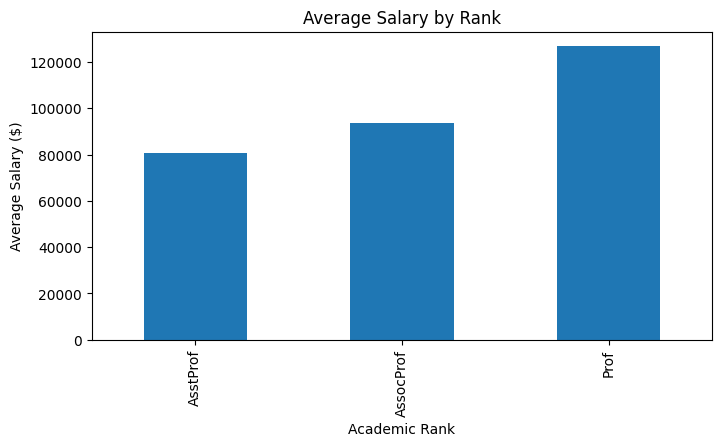

In [183]:
# Cell 16
# Purpose: Create a bar chart showing the average salary by academic rank.
# Visualize how compensation changes across
#     Assistant Professors, Associate Professors,
#     and Professors.
import matplotlib.pyplot as plt
ax = (
    salary_df.groupby('Rank')['Salary']
    .mean()
    .sort_values(ascending=True)
    .plot(
        kind='bar',
        figsize=(8,4),
        title='Average Salary by Rank'
    )
)

ax.set_xlabel('Academic Rank')
ax.set_ylabel('Average Salary ($)')

plt.show()

In [184]:
# Cell 16 Quick Analysis:
# Professors have the highest average salary.
# Associate Professors have the second highest average salary.
# Assistant Professors have the lowest average salary.
# The chart suggests that academic rank is strongly
# associated with compensation levels.

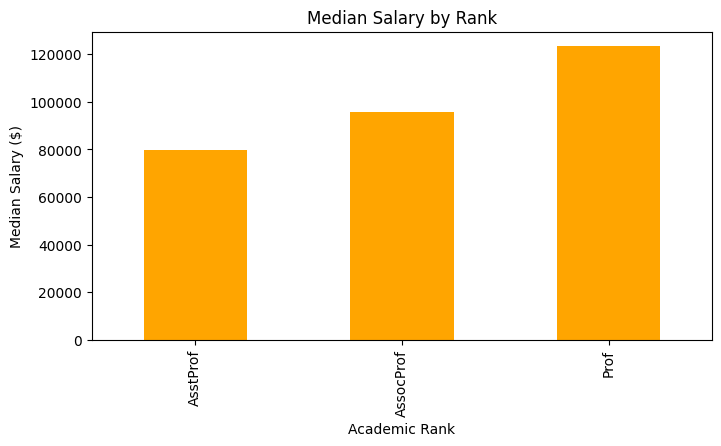

In [185]:
# Cell 17
# Purpose:
# Create a bar chart showing the median salary by academic rank.
# Compare the typical salary within each rank while
#     reducing the influence of unusually high salaries.

ax = (
    salary_df.groupby('Rank')['Salary']
    .median()
    .sort_values(ascending=True)
    .plot(
        kind='bar',
        figsize=(8,4),
        title='Median Salary by Rank',
        color='orange'
    )
)

ax.set_xlabel('Academic Rank')
ax.set_ylabel('Median Salary ($)')

plt.show()

In [186]:
# Cell 17 Quick Analysis:
# Both mean and median salary charts show a consistent increase
#     in compensation from Assistant Professor to Professor.
# The similar patterns suggest that the salary differences are
#     broadly distributed across ranks rather than being caused by a few outliers.
# Academic rank appears strongly associated with salary levels.

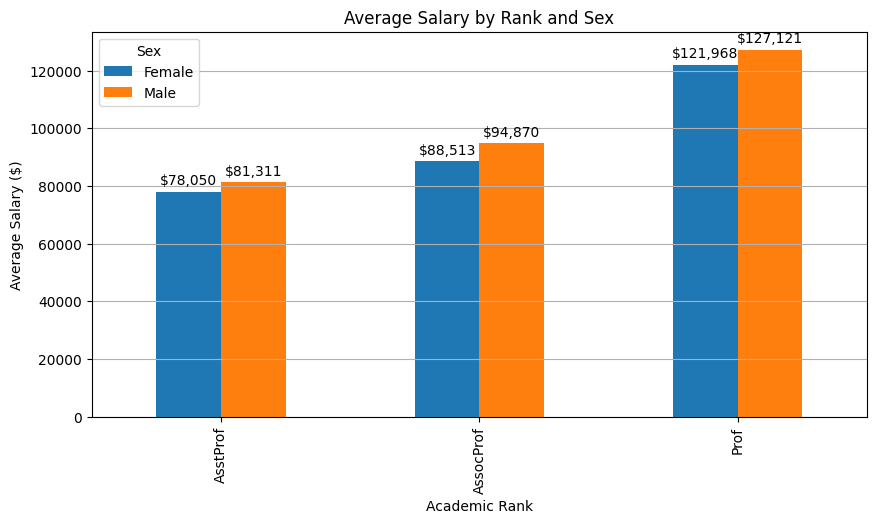

In [187]:
# Cell 17
# Purpose:
# Create a grouped bar chart showing the average salary
# by academic rank and sex.
#
# Compare compensation levels within each rank and identify
# potential salary differences between Male and Female faculty.
# Sorting the ranks from lowest to highest average salary makes
# the progression easier to interpret.

salary_rank_sex_mean = (
    salary_df
    .groupby(['Rank', 'Sex'])['Salary']
    .mean()
    .unstack()
) # unsstack Moves Female and Male into separate columns.

# Sort ranks by overall average salary
rank_order = (
    salary_df
    .groupby('Rank')['Salary']
    .mean()
    .sort_values(ascending=True)
    .index
) # index uses the Rank labels

# Return these rows in the exact order after sorting in the above code.
salary_rank_sex_mean = salary_rank_sex_mean.loc[rank_order]

ax = salary_rank_sex_mean.plot(
    kind='bar',
    figsize=(10,5),
    title='Average Salary by Rank and Sex'
)

ax.set_xlabel('Academic Rank')
ax.set_ylabel('Average Salary ($)')

ax.grid(True, axis='y')

# Add salary labels above each bar
for container in ax.containers: # Container 1 = Female bars 2= Male bars
    labels = [f'${v:,.0f}' for v in container.datavalues] # Extract the Values
    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.show()

In [188]:
# Cell 17 Quick Analysis:
# Salary generally increases from Assistant Professor
# to Associate Professor to Professor.
# Male and Female salary trends appear similar
# within each academic rank.

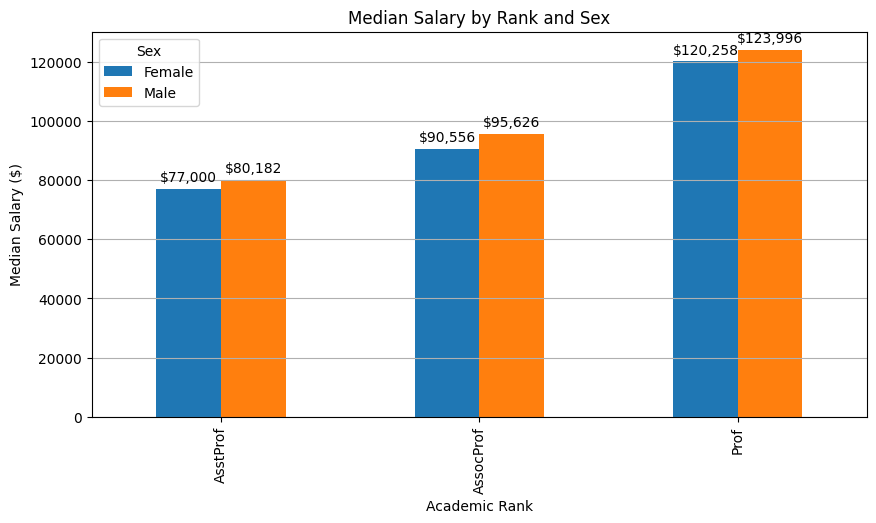

In [189]:
# Cell 18
# Purpose:Create a grouped bar chart showing the median salary
# by academic rank and sex.

# Compare the typical salary within each rank while reducing
# the effect of unusually high or low salary values.
# Median salaries provide a more robust measure of central tendency.

salary_rank_sex_median = (
    salary_df
    .groupby(['Rank','Sex'])['Salary']
    .median()
    .unstack()
)

# Sort ranks by overall median salary
rank_order = (
    salary_df
    .groupby('Rank')['Salary']
    .median()
    .sort_values(ascending=True)
    .index
)

salary_rank_sex_median = salary_rank_sex_median.loc[rank_order]

ax = salary_rank_sex_median.plot(
    kind='bar',
    figsize=(10,5),
    title='Median Salary by Rank and Sex'
)

ax.set_xlabel('Academic Rank')
ax.set_ylabel('Median Salary ($)')

ax.grid(True, axis='y')

# Add salary labels above each bar
for container in ax.containers:
    labels = [f'${v:,.0f}' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.show()

In [190]:
# Cell 17 and 18 Quick Analysis:
# The mean and median salary charts show similar patterns.
# Professors have the highest compensation levels,
# followed by Associate Professors and Assistant Professors.
# The consistency between both measures suggests that
# salary differences by rank are broadly distributed
# and not caused solely by a small number of outliers.

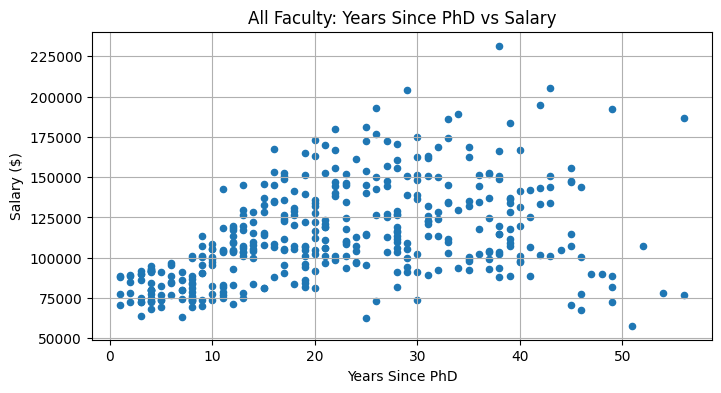

In [191]:
# Cell 19
# All Faculty Scatter
# Purpose:Create a scatter plot comparing Years_Since_PhD and Salary.
# Determine whether faculty experience  is associated with salary.
# Each point represents one faculty member.
# The chart helps identify trends, clusters, and potential outliers.
# A positive relationship would suggest that salary generally
# increases as years of experience increase.
# dataframe salary_df was created in a previous cell.
ax = salary_df.plot(
    kind='scatter',
    x='Years_Since_PhD',
    y='Salary',
    figsize=(8,4),
    title='All Faculty: Years Since PhD vs Salary'
)

ax.set_xlabel('Years Since PhD')
ax.set_ylabel('Salary ($)')

ax.grid(True)

plt.show()

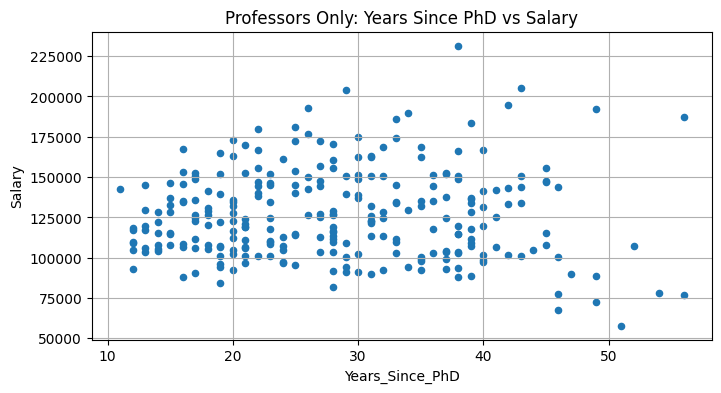

In [192]:
# Cell 20
# Professors Only
prof_df.plot(kind='scatter', x='Years_Since_PhD', y='Salary', figsize=(8,4), title='Professors Only: Years Since PhD vs Salary', grid=True)
plt.show()


In [193]:
# CELL 20 Quick Analysis:
# Professors show wider salary variation and several high salary observations.

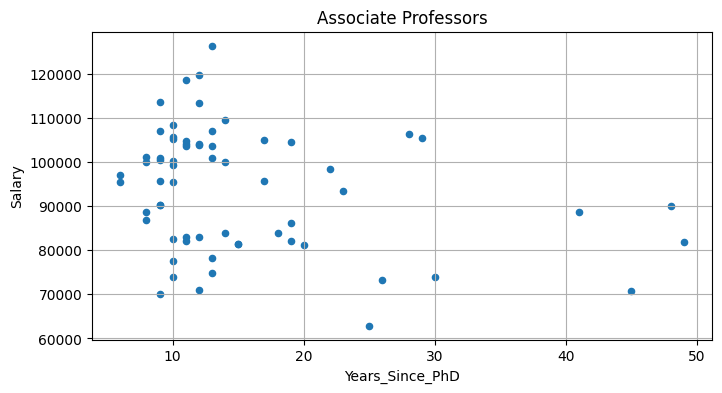

In [194]:
# Cell 21
# Associate Professors Only
assoc_df = salary_df[salary_df['Rank']=='AssocProf']
assoc_df.plot(kind='scatter', x='Years_Since_PhD', y='Salary', figsize=(8,4), title='Associate Professors', grid=True)
plt.show()

In [195]:
# CELL21 Quick Analysis:
# Associate Professors show a narrower salary spread than Professors.

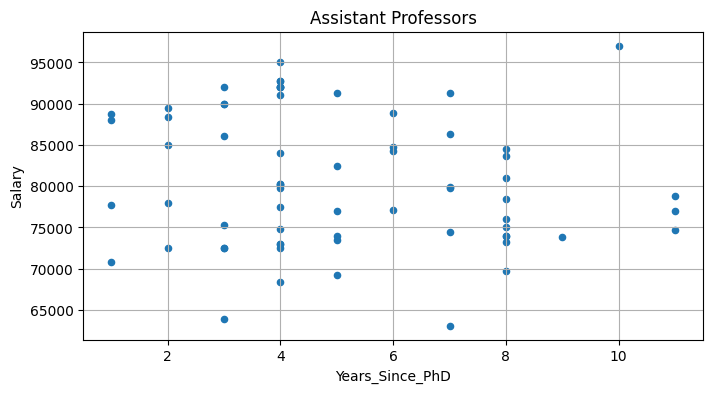

In [196]:
# Cell 22
# Assistant Professors Only
asst_df = salary_df[salary_df['Rank']=='AsstProf']
asst_df.plot(kind='scatter', x='Years_Since_PhD', y='Salary', figsize=(8,4), title='Assistant Professors', grid=True)
plt.show()

In [197]:
# CELL 22 Quick Analysis:
# Assistant Professors have the lowest salary range and tighter clustering.


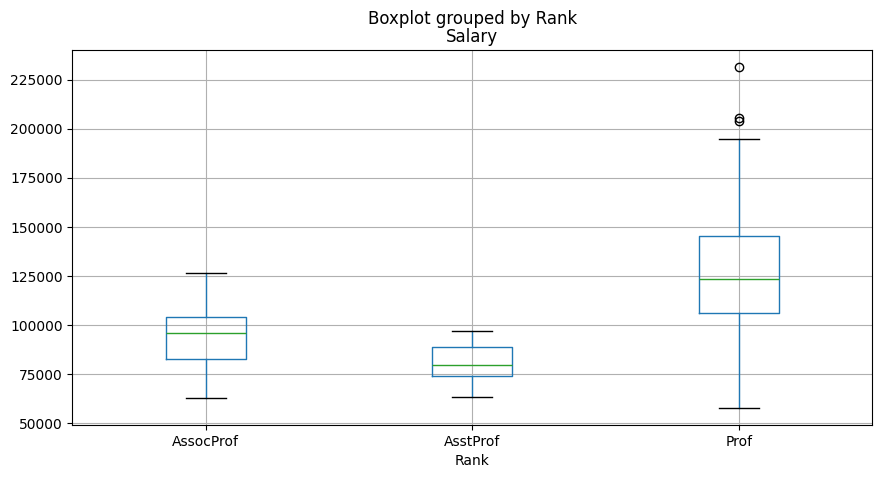

In [198]:
# Cell 23
# Salary boxplot by Rank
# Quick Analysis:
# Boxplot highlights salary variability and potential outliers by rank.

salary_df.boxplot(column='Salary', by='Rank', figsize=(10,5))
plt.show()

In [199]:
# Cell 23 Quick Analysis:
# Professors display the highest median salary and the greatest salary variability.
# Assistant Professors have the lowest median salary and the smallest salary spread.
# Associate Professors fall between Assistant Professors and Professors
# Several high-salary outliers are visible in the Professor group,
# indicating that some Professors earn substantially more than their peers.
# The wider Professor box and whiskers suggest greater salary dispersion,
# while Assistant Professor salaries appear more concentrated.
# Overall, the boxplot supports previous findings that salary generally
# increases with academic rank.

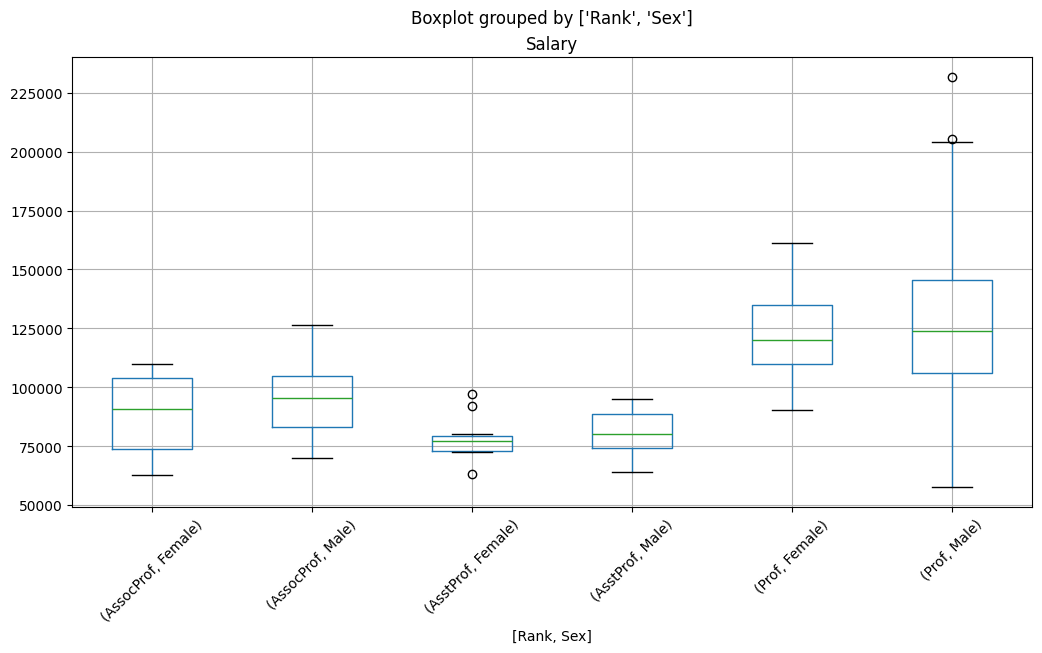

In [200]:
# CELL 24
salary_df.boxplot(column='Salary', by=['Rank','Sex'], figsize=(12,6), rot=45)
plt.show()

In [201]:
# Cell 24
# Quick Analysis: Median salary generally increases with academic rank.
# Male and Female salary distributions appear broadly similar within each rank.
# Male Professors show the highest salary variability and contain the most visible outliers.
# Female Professors do not appear to have salary outliers in this sample.

In [202]:
# Cell 25
# Purpose:Create a summary comparison table for academic ranks.
# Consolidate key findings from previous statistical analyses
# The table provides a high-level comparison of salary range,
# salary variability, experience impact, and outlier presence
# across faculty ranks.

comparison_df = pd.DataFrame({
    'Observation':['Salary Range','High Salary Outliers','Experience Effect','Salary Variability'],
    'Professors':['Very Large','Many','Moderate','Very High'],
    'Associate Professors':['Moderate','None','Weak','Lower']
})
print(comparison_df)


            Observation  Professors Associate Professors
0          Salary Range  Very Large             Moderate
1  High Salary Outliers        Many                 None
2     Experience Effect    Moderate                 Weak
3    Salary Variability   Very High                Lower


In [203]:
# Cell 25 Quick Analysis:
# Professors have the highest salaries, the greatest salary variability,
# and the most visible salary outliers.
# Associate Professors show more moderate salaries and less variability.
# The summary table reinforces previous findings that salary generally
# increases with academic rank and experience.

In [204]:
# ============================================================
# PART 7 - CONCLUSIONS
# ============================================================


In [205]:
# Cell 26
print('===== CONCLUSIONS =====')
print(f'Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns')
print('- No missing values were found')
print('- No duplicate records were identified')
print('- Rank appears to influence salary more strongly than experience alone')
print('- High salary outliers appear to be legitimate Professor salaries')
print('- Experience has a moderate effect among Professors and weaker effect in lower ranks')

# Summarize findings identified through exploration and visualization.


===== CONCLUSIONS =====
Dataset Size: 397 rows and 8 columns
- No missing values were found
- No duplicate records were identified
- Rank appears to influence salary more strongly than experience alone
- High salary outliers appear to be legitimate Professor salaries
- Experience has a moderate effect among Professors and weaker effect in lower ranks


In [206]:
# ============================================================
# PART 8 - EXPORT CSV
# ============================================================


In [207]:
# Cell 27
salary_df.to_csv('salaries_final.csv', index=False)
print('salaries_tableau.csv exported successfully')

# Why:
# Export Tableau ready dataset for dashboard development.

salaries_tableau.csv exported successfully


In [208]:
# Cell 28
from google.colab import files
files.download('salaries_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>